### Analise de Churn

## 1. Importação dos dados e Bibliotecas

In [69]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

c:\Users\Hugo\Documents\Projetos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Hugo\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans, SpectralClustering
from pretty_confusion_matrix import pp_matrix_from_data


## 2. Tratamento dos dados

In [2]:
df = pd.read_csv('data/Telco-Customer-Churn.csv')

# Tratamento dos dados, alterando dados categóricos para numéricos
df.replace('Yes', 1, inplace=True)
df.replace('No', 0, inplace=True)
df.TotalCharges = df.TotalCharges.replace(' ',0).astype('float64')

# separação das variáveis preditoras e variável alvo
df_y = df.Churn
df_var = df.drop('Churn', axis=1)
df_var = df_var.drop(['customerID'], axis=1)

# normalização dos dados
scaler = StandardScaler()
# df_var[['MonthlyCharges', 'TotalCharges']] = pd.DataFrame(
#     scaler.fit_transform(df_var[['MonthlyCharges', 'TotalCharges']]),
#     columns=['MonthlyCharges', 'TotalCharges']
# )

df.head()

C:\Users\Hugo\AppData\Local\Temp\ipykernel_23204\4144764799.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('No', 0, inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [3]:
# Criação de variáveis dummy para as colunas categóricas
cols_categoricas = df_var.select_dtypes(include=["object", "category"]).columns
df_dummies = pd.get_dummies(df, columns=cols_categoricas, drop_first=True)
df_dummies.drop(['customerID'], axis=1, inplace=True)
df_dummies.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,False,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


In [4]:
df_dummies_scaled = pd.DataFrame(
                        scaler.fit_transform(df_dummies.drop('Churn',axis=1)),
                        columns=df_dummies.drop('Churn',axis=1).columns)
df_dummies_scaled['Churn'] = df_dummies['Churn']

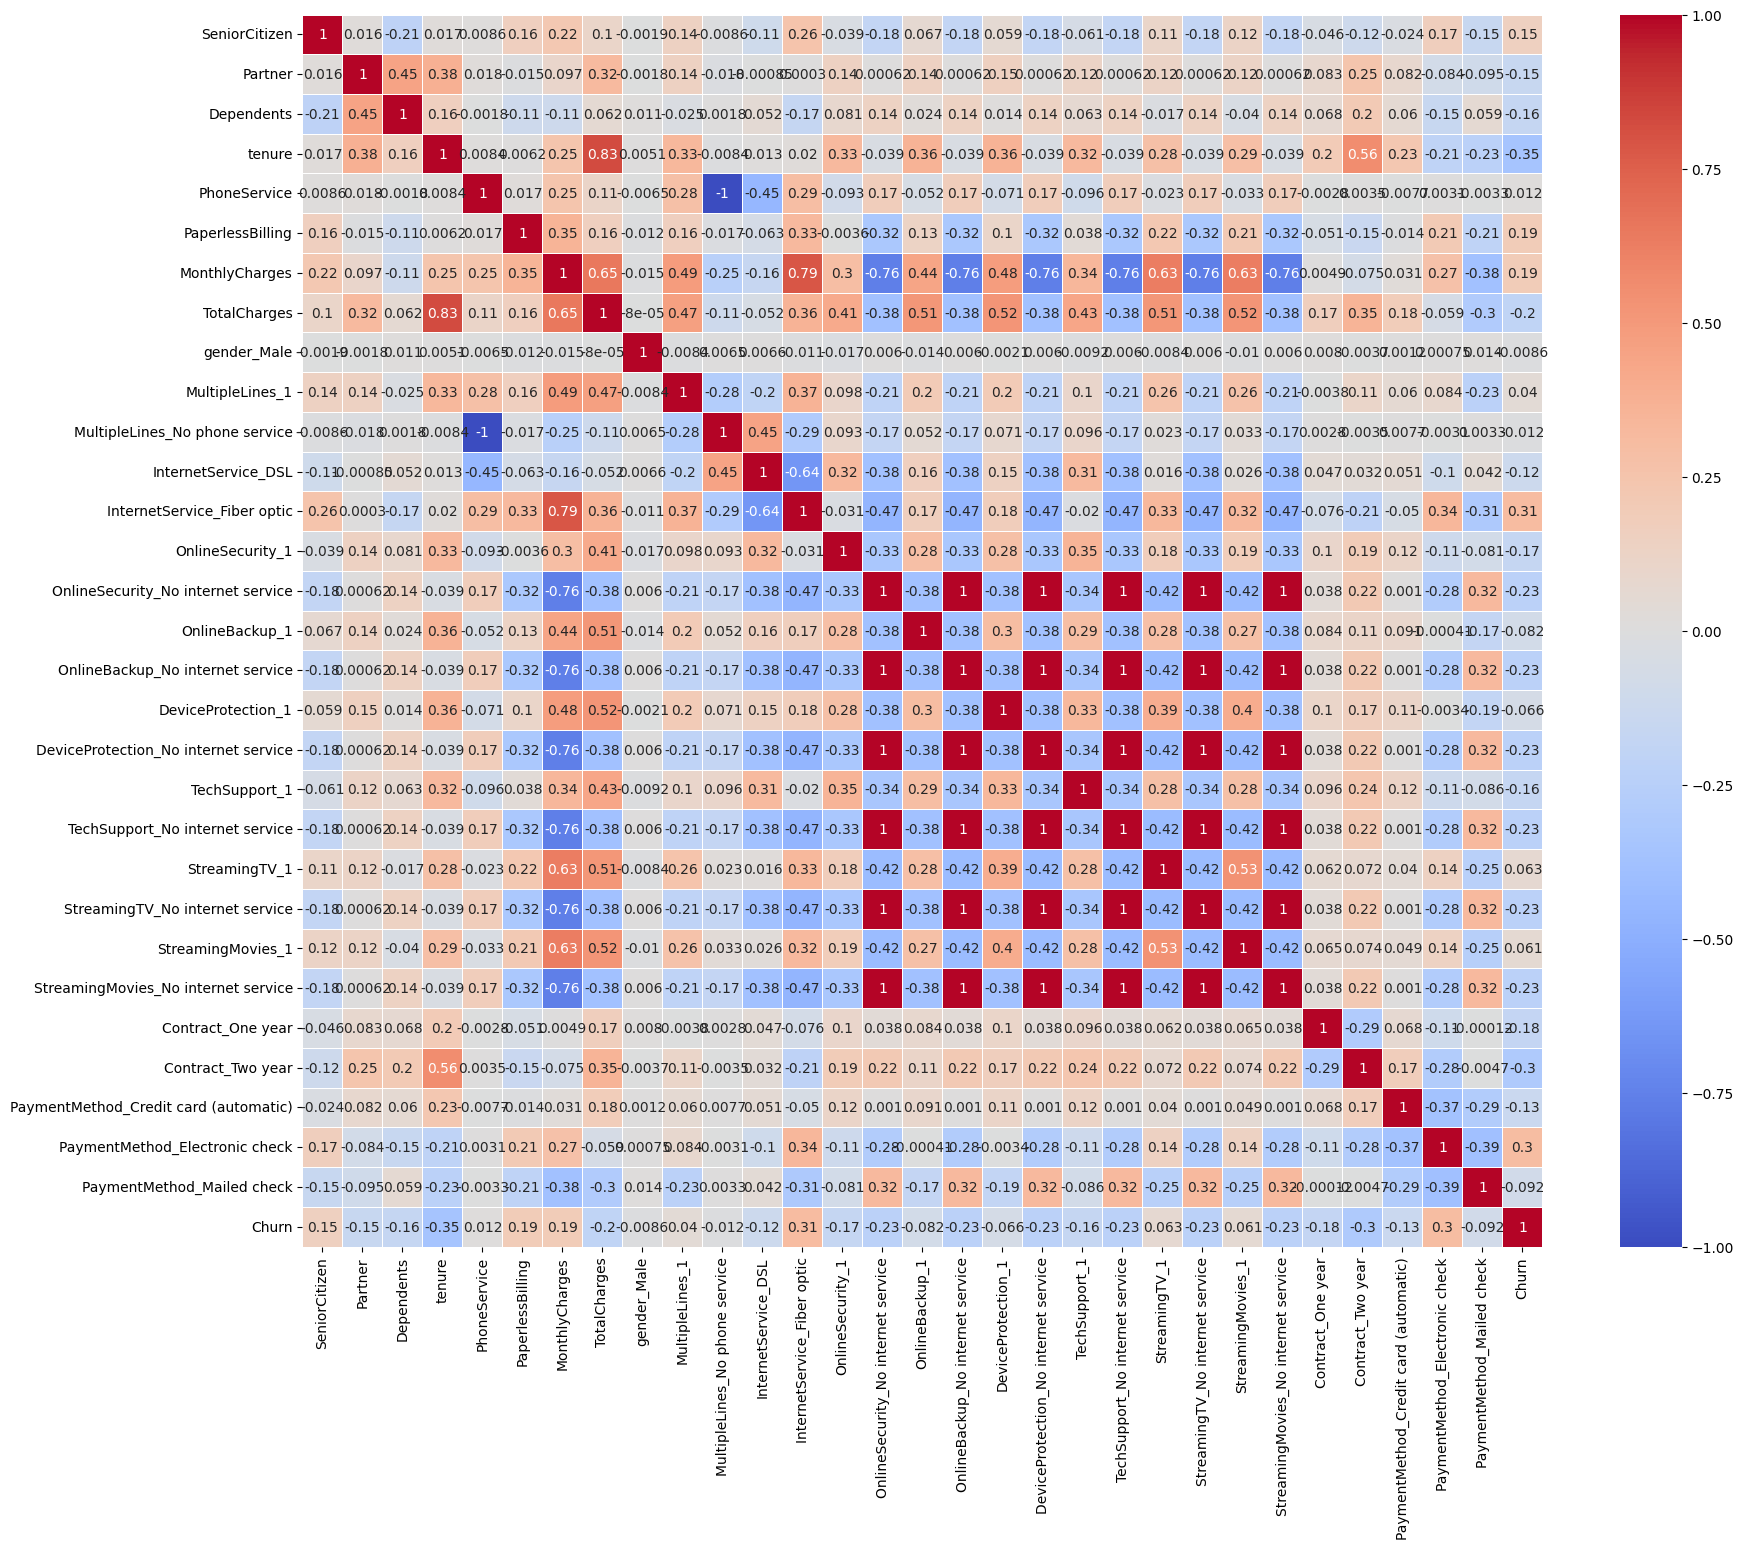

In [5]:
corr = df_dummies_scaled.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.show()


In [6]:
# Análise das correlações

print('5 Maiores correlações \n', corr['Churn'].sort_values(ascending=False)[1:6])

print('\n5 menores correlações \n' ,corr['Churn'].sort_values(ascending=True)[:5])

# Aqui vemos que não temos correlações muito altas com a variável alvo, o que pode indicar que o problema é mais complexo.

5 Maiores correlações 
 InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
Name: Churn, dtype: float64

5 menores correlações 
 tenure                                 -0.352229
Contract_Two year                      -0.302253
TechSupport_No internet service        -0.227890
OnlineSecurity_No internet service     -0.227890
DeviceProtection_No internet service   -0.227890
Name: Churn, dtype: float64


In [7]:
X = df_dummies_scaled.drop('Churn', axis=1)
y = df_dummies_scaled['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)


# Modelagens

In [8]:
def plot_confusion_matrix(cf_matrix, ax):
    group_names = ['True Neg','False Pos','False Neg','True Pos']
    group_counts = ['{0:0.0f}'.format(value) for value in
                    cf_matrix.flatten()]
    group_percentages = ['{0:.2%}'.format(value) for value in
                        cf_matrix.flatten()/np.sum(cf_matrix)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in
            zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues', ax=ax)
    return

### Modelo de Regressão

In [9]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)
prob = pd.DataFrame(model.predict_proba(X_test)[:, 1], columns=['Churn_Prob'] )

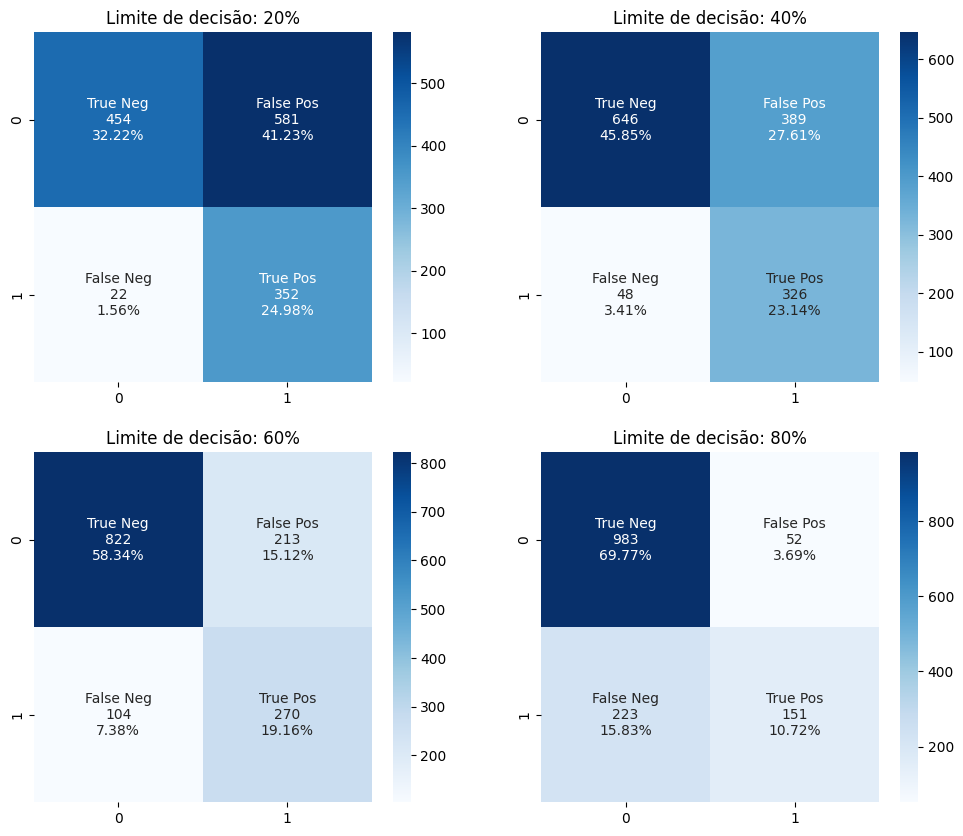

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

probabilidade = 0.2
for i in [0,1]:
    for j in [0,1]:

        y_pred = prob.copy()
        y_pred.loc[prob.Churn_Prob >= probabilidade, 'Churn_Prob'] = int(1)
        y_pred.loc[prob.Churn_Prob < probabilidade, 'Churn_Prob'] = int(0)
        y_pred = y_pred['Churn_Prob'].to_list()
        y_pred = [int(float(x)) for x in y_pred]

        cf_matrix = confusion_matrix(y_test, y_pred)
        axes [i,j].set_title(f'Limite de decisão: {probabilidade*100:.0f}%')
        ax = axes[i,j]
        plot_confusion_matrix(cf_matrix, ax)
        probabilidade+=0.2

## Modelo Random Forest

In [91]:
model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)
prob = pd.DataFrame(model.predict_proba(X_test)[:, 1], columns=['Churn_Prob'] )

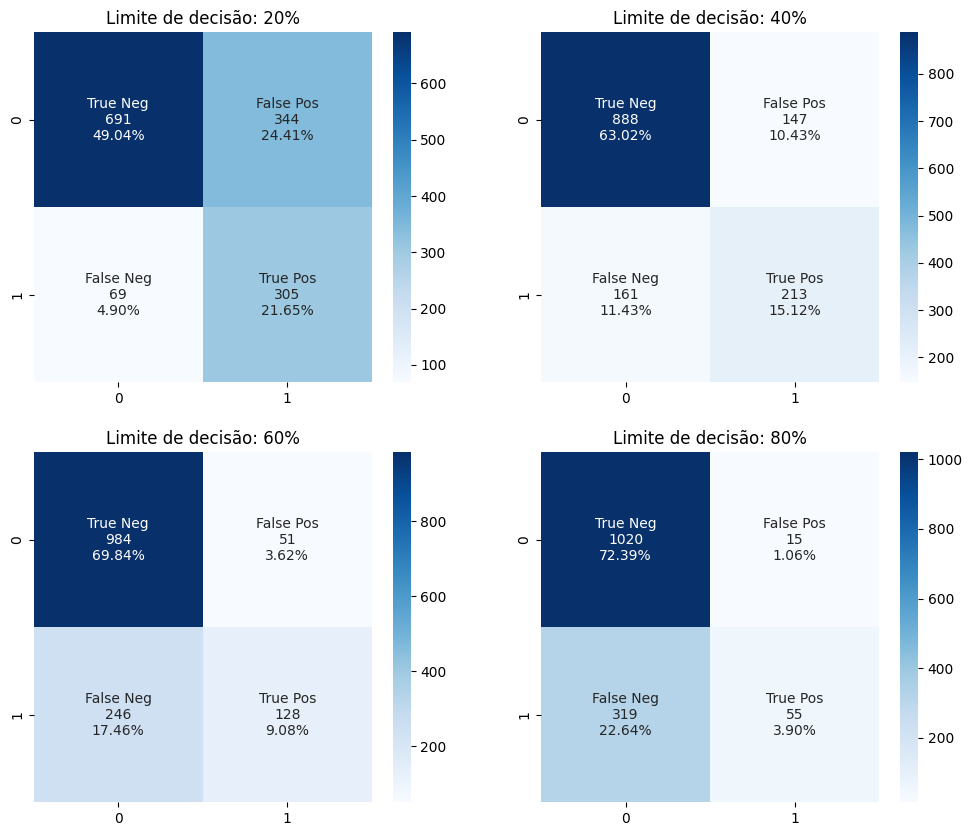

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

probabilidade = 0.2
for i in [0,1]:
    for j in [0,1]:

        y_pred = prob.copy()
        y_pred.loc[prob.Churn_Prob >= probabilidade, 'Churn_Prob'] = int(1)
        y_pred.loc[prob.Churn_Prob < probabilidade, 'Churn_Prob'] = int(0)
        y_pred = y_pred['Churn_Prob'].to_list()
        y_pred = [int(float(x)) for x in y_pred]

        cf_matrix = confusion_matrix(y_test, y_pred)
        axes [i,j].set_title(f'Limite de decisão: {probabilidade*100:.0f}%')
        ax = axes[i,j]
        plot_confusion_matrix(cf_matrix, ax)
        probabilidade+=0.2

## Modelo Gradient Boosting


In [26]:
model = GradientBoostingClassifier(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=5
            )
model.fit(X_train, y_train)
prob = pd.DataFrame(model.predict_proba(X_test)[:, 1], columns=['Churn_Prob'] )

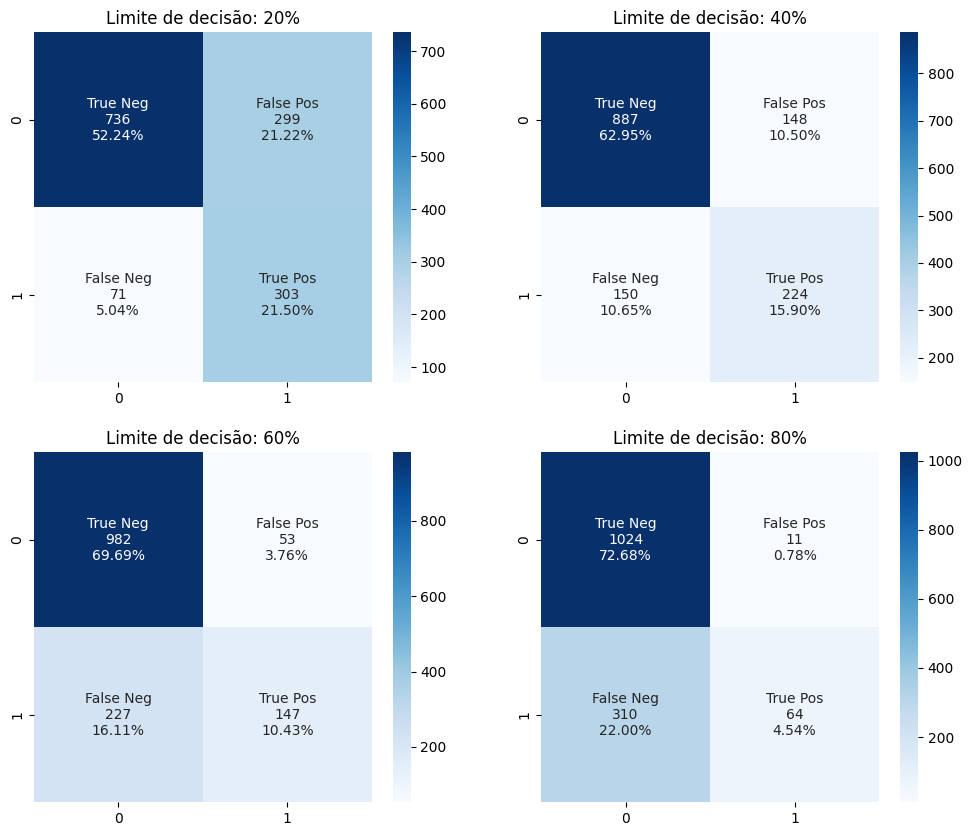

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

probabilidade = 0.2
for i in [0,1]:
    for j in [0,1]:

        y_pred = prob.copy()
        y_pred.loc[prob.Churn_Prob >= probabilidade, 'Churn_Prob'] = int(1)
        y_pred.loc[prob.Churn_Prob < probabilidade, 'Churn_Prob'] = int(0)
        y_pred = y_pred['Churn_Prob'].to_list()
        y_pred = [int(float(x)) for x in y_pred]

        cf_matrix = confusion_matrix(y_test, y_pred)
        axes [i,j].set_title(f'Limite de decisão: {probabilidade*100:.0f}%')
        ax = axes[i,j]
        plot_confusion_matrix(cf_matrix, ax)
        probabilidade+=0.2

## Redes Neurais

In [44]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=10000
)
model.fit(X_train, y_train)
prob = pd.DataFrame(model.predict_proba(X_test)[:, 1], columns=['Churn_Prob'] )

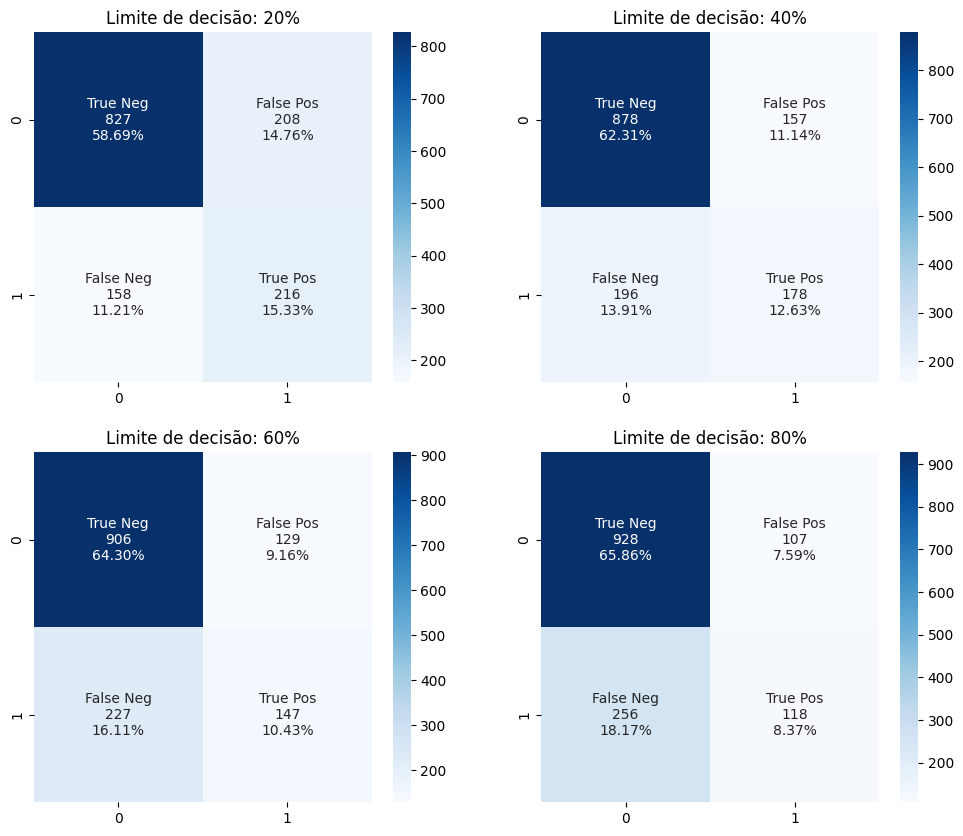

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

probabilidade = 0.2
for i in [0,1]:
    for j in [0,1]:

        y_pred = prob.copy()
        y_pred.loc[prob.Churn_Prob >= probabilidade, 'Churn_Prob'] = int(1)
        y_pred.loc[prob.Churn_Prob < probabilidade, 'Churn_Prob'] = int(0)
        y_pred = y_pred['Churn_Prob'].to_list()
        y_pred = [int(float(x)) for x in y_pred]

        cf_matrix = confusion_matrix(y_test, y_pred)
        axes [i,j].set_title(f'Limite de decisão: {probabilidade*100:.0f}%')
        ax = axes[i,j]
        plot_confusion_matrix(cf_matrix, ax)
        probabilidade+=0.2

# Analise de recuperação

A partir de uma hipotese (dando X% de desconto resultaria na retenção de tantos % de clientes), calcular qual o valor que será retido

In [97]:
df_recuperacao = pd.DataFrame(df_var.iloc[X_test.index].MonthlyCharges)
df_recuperacao['y_test'] = y_test
df_recuperacao['y_pred'] = prob['Churn_Prob'].to_list()

In [99]:
# Supondo que dando um desconto de 30% para clientes com probabilidade de churn maior que 40% resulte que 60% fiquem
desconto = 0.3
retencao = 0.6
churn_threshold = 0.4

print('Valor total de destratos: ',round(df_recuperacao.loc[df_recuperacao['y_test'] == 1].MonthlyCharges.sum(),2))
print('Valor total recuperado dos destratos: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==1)].MonthlyCharges.sum()*retencao, 2))
print('Valor dos descontos dos falsos detratores: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==0)].MonthlyCharges.sum()*desconto, 2))
print('Valor recuperado: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==1)].MonthlyCharges.sum()*retencao - df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==0)].MonthlyCharges.sum()*desconto, 2))


Valor total de destratos:  27343.75
Valor total recuperado dos destratos:  10010.91
Valor dos descontos dos falsos detratores:  3304.06
Valor recuperado:  6706.84


In [100]:
# Supondo que dando um desconto de 30% para clientes com probabilidade de churn maior que 60% resulte que 60% fiquem
desconto = 0.3
retencao = 0.6
churn_threshold = 0.6

print('Valor total de destratos: ',round(df_recuperacao.loc[df_recuperacao['y_test'] == 1].MonthlyCharges.sum(),2))
print('Valor total recuperado dos destratos: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==1)].MonthlyCharges.sum()*retencao, 2))
print('Valor dos descontos dos falsos detratores: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==0)].MonthlyCharges.sum()*desconto, 2))
print('Valor recuperado: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==1)].MonthlyCharges.sum()*retencao - df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==0)].MonthlyCharges.sum()*desconto, 2))


Valor total de destratos:  27343.75
Valor total recuperado dos destratos:  6052.65
Valor dos descontos dos falsos detratores:  1267.48
Valor recuperado:  4785.16


In [102]:
# Supondo que dando um desconto de 30% para clientes com probabilidade de churn maior que 20% resulte que 60% fiquem
desconto = 0.3
retencao = 0.6
churn_threshold = 0.2

print('Valor total de destratos: ',round(df_recuperacao.loc[df_recuperacao['y_test'] == 1].MonthlyCharges.sum(),2))
print('Valor total recuperado dos destratos: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==1)].MonthlyCharges.sum()*retencao, 2))
print('Valor dos descontos dos falsos detratores: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==0)].MonthlyCharges.sum()*desconto, 2))
print('Valor recuperado: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==1)].MonthlyCharges.sum()*retencao - df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==0)].MonthlyCharges.sum()*desconto, 2))


Valor total de destratos:  27343.75
Valor total recuperado dos destratos:  14173.35
Valor dos descontos dos falsos detratores:  7677.46
Valor recuperado:  6495.89


In [103]:
# Supondo que dando um desconto de 30% para clientes com probabilidade de churn maior que 20% resulte que 60% fiquem
desconto = 0.3
retencao = 0.6
churn_threshold = 0.8

print('Valor total de destratos: ',round(df_recuperacao.loc[df_recuperacao['y_test'] == 1].MonthlyCharges.sum(),2))
print('Valor total recuperado dos destratos: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==1)].MonthlyCharges.sum()*retencao, 2))
print('Valor dos descontos dos falsos detratores: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==0)].MonthlyCharges.sum()*desconto, 2))
print('Valor recuperado: ',round(df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==1)].MonthlyCharges.sum()*retencao - df_recuperacao.loc[(df_recuperacao['y_pred']>=churn_threshold)*(df_recuperacao.y_test==0)].MonthlyCharges.sum()*desconto, 2))


Valor total de destratos:  27343.75
Valor total recuperado dos destratos:  2578.98
Valor dos descontos dos falsos detratores:  376.65
Valor recuperado:  2202.33


In [12]:
# Criação de variáveis dummy para as colunas categóricas
cols_categoricas = df_var.select_dtypes(include=["object", "category"]).columns
df_dummies = pd.get_dummies(df, columns=cols_categoricas, drop_first=True)
df_dummies.drop(['customerID'], axis=1, inplace=True)
df_dummies = df_dummies.loc[df_dummies['Churn']==1]
df_dummies.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False
5,0,0,0,8,1,1,99.65,820.50,1,False,...,False,True,False,True,False,False,False,False,True,False
8,0,1,0,28,1,1,104.80,3046.05,1,False,...,False,True,False,True,False,False,False,False,True,False
13,0,0,0,49,1,1,103.70,5036.30,1,True,...,False,True,False,True,False,False,False,False,False,False


In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_dummies.drop('Churn',axis=1))

# PCA
pca = PCA(n_components=17)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17'])



In [55]:
clustering = KMeans(n_clusters=6).fit(X_pca)

X_pca['cluster'] = clustering.labels_

In [57]:
X_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,cluster
0,1.140779,2.297975,0.765936,-2.297313,-0.607586,-0.496734,0.030582,1.446741,1.486926,-1.118802,1.426563,0.733612,1.694934,1.374165,0.277944,0.313505,1.181879,3
1,0.090201,1.082047,-2.252877,-0.208574,0.096163,-0.014936,0.796088,-0.941955,-0.064554,0.083214,0.753304,0.157448,-0.147504,-0.109803,-0.288970,-0.973058,-0.507266,0
2,-1.560302,-0.744444,-1.430502,0.962033,-0.311260,-1.495600,0.165553,-0.657191,-1.356661,0.221328,-0.134601,-0.174018,-0.090109,0.634008,-1.271522,0.712839,0.133538,0
3,-2.279493,-1.796858,0.226388,0.679882,0.555994,-1.412757,0.412166,-0.673615,-1.326239,-0.077374,-0.419251,0.853947,-1.438946,-0.008024,0.003638,1.194145,-1.002366,4
4,-2.334075,-2.297808,0.787104,0.658008,-1.069887,-0.739822,-0.571029,1.272504,-0.048583,0.570248,1.251843,-1.120127,0.437567,0.630194,-0.572576,0.504673,0.245061,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,0.019074,1.356927,1.240329,-0.335805,0.175095,-2.437295,0.312616,-0.636494,2.441649,1.244660,-0.005782,1.822649,-1.668620,-1.257824,0.176538,-0.791860,0.736486,3
1865,1.124198,2.442709,-0.209923,-1.174549,-0.476201,0.128256,0.470306,-0.402549,-0.001187,0.051371,0.645397,0.597042,-0.424195,-0.416883,-1.248178,-0.448562,1.016132,3
1866,-0.411181,0.543689,-2.504488,0.619846,-0.504543,1.027948,0.091258,0.947171,1.037534,-0.115757,-0.483908,0.680920,-0.495520,-0.208493,-0.028674,0.304557,-0.234287,0
1867,-2.535283,-2.719709,2.195968,-1.261689,-2.323402,1.310168,0.533567,-0.895494,0.001609,0.095606,1.070319,-0.524400,1.446670,1.692559,-1.069206,0.329668,-0.550831,2


In [56]:
import plotly.express as px

fig = px.scatter_3d(
    X_pca,
    x='PC1',
    y="PC2",
    z="PC3",
    color="cluster",         
    opacity=0.7
)

fig.update_layout(title="Scatter 3D Interativo")
fig.show()

